In [27]:
from sys import stdout

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [28]:
# Absorbance data, collected in the matrix X
data=pd.read_excel(r"/Users/macbook/Documents/data/FL200_N.xlsx").values
X = data[:,1:]
y = data[:,0]
wl = np.linspace(942, 1701, X.shape[1])

/Users/macbook/opt/anaconda3/lib/python3.9/site-packages/sklearn/cross_decomposition/_pls.py:503: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(


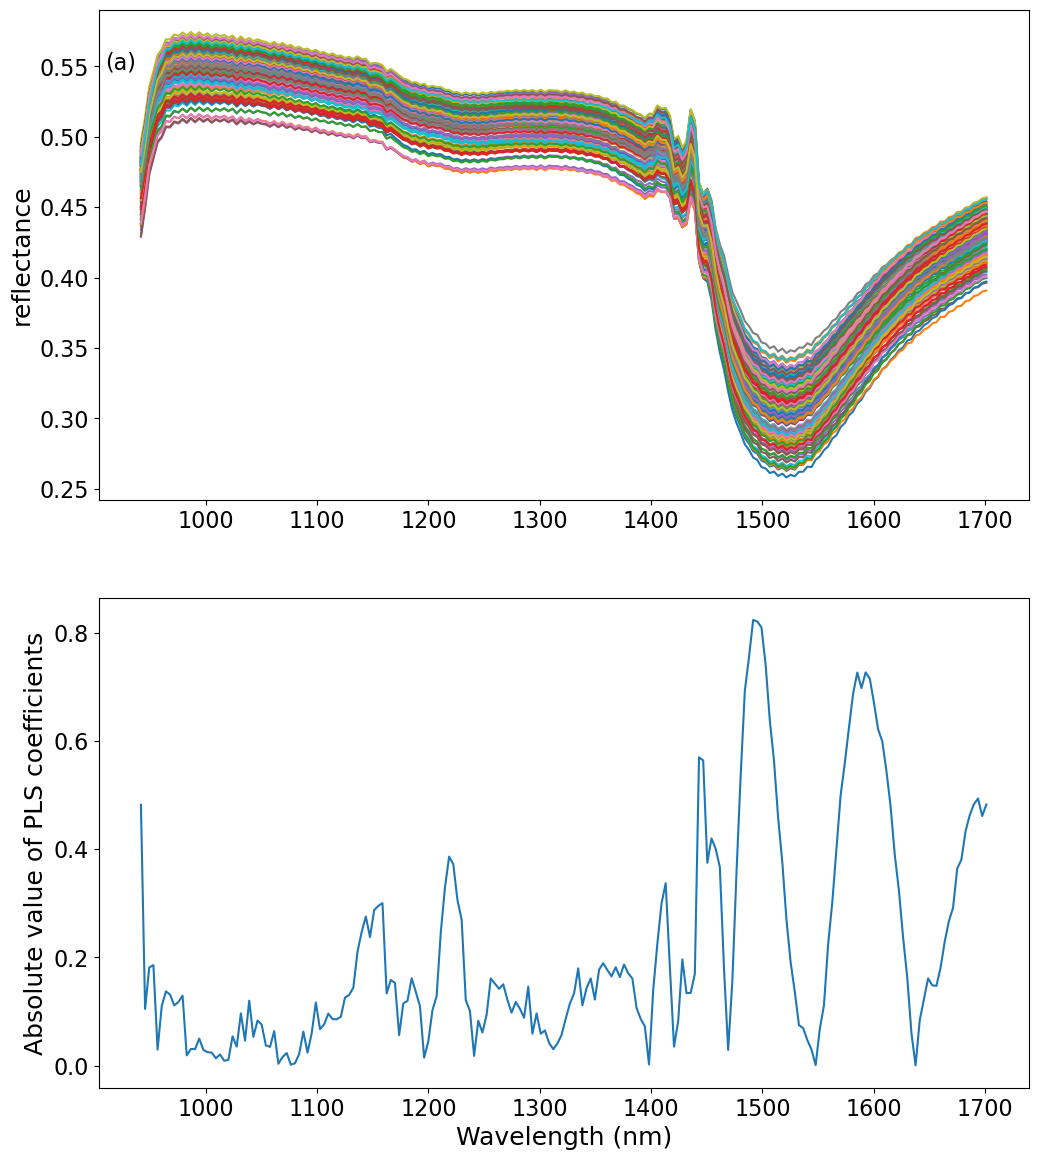

In [38]:
# Define the PLS regression object
pls = PLSRegression(n_components=8)
# Fit data
pls.fit(X, y)

# Plot spectra
plt.figure(figsize=(12,14))
with plt.style.context(()):
    ax1 = plt.subplot(211)
    plt.plot(wl, X.T)
    plt.text(910, 0.51, "(a)\n\n", fontsize=16, color='black') 
    plt.xticks(fontsize=16)  
    plt.yticks(fontsize=16)
    plt.ylabel('reflectance', fontsize=18)

    ax2 = plt.subplot(212, sharex=ax1)
    plt.plot(wl, np.abs(pls.coef_[:,0]))
    plt.xticks(fontsize=16)  
    plt.yticks(fontsize=16)
    plt.xlabel('Wavelength (nm)', fontsize=18)
    plt.ylabel('Absolute value of PLS coefficients', fontsize=18)

    plt.show()

In [30]:
pls.coef_[:,0]

array([-4.82141800e-01,  1.04977265e-01,  1.81552621e-01,  1.85926296e-01,
        2.98425371e-02, -1.10230055e-01, -1.37432433e-01, -1.31417670e-01,
       -1.11567391e-01, -1.17711020e-01, -1.29577003e-01, -1.93444344e-02,
       -3.09742435e-02,  3.06436069e-02, -5.01789685e-02,  2.92409165e-02,
        2.50821625e-02,  2.42548649e-02, -1.37264193e-02, -2.08694380e-02,
        9.22363690e-03, -1.09794388e-02, -5.43181473e-02, -3.53500788e-02,
       -9.68238358e-02, -4.63344633e-02, -1.20227297e-01, -5.33288349e-02,
       -8.34716718e-02, -7.59255697e-02, -3.74707975e-02, -3.49328112e-02,
       -6.39903593e-02, -3.72160427e-03, -1.61950931e-02, -2.35445211e-02,
        1.91867610e-03,  4.64815041e-03,  2.17763805e-02,  6.31396886e-02,
        2.41420139e-02,  5.99343315e-02,  1.16837259e-01,  6.75479267e-02,
        7.66044155e-02,  9.63637610e-02,  8.62538356e-02,  8.57969117e-02,
        9.04647530e-02,  1.25984426e-01,  1.30735546e-01,  1.44189054e-01,
        2.10559756e-01,  

In [31]:
# Get the list of indices that sorts the PLS coefficients in ascending order
# of the absolute value
sorted_ind = np.argsort(np.abs(pls.coef_[:,0]))

# Sort spectra according to ascending absolute value of PLS coefficients
Xc = X[:,sorted_ind]

In [32]:
def pls_variable_selection(X, y, max_comp):

    # Define MSE array to be populated
    mse = np.zeros((max_comp,X.shape[1]))

    # Loop over the number of PLS components
    for i in range(max_comp):

        # Regression with specified number of components, using full spectrum
        pls1 = PLSRegression(n_components=i+1)
        pls1.fit(X, y)

        # Indices of sort spectra according to ascending absolute value of PLS coefficients
        sorted_ind = np.argsort(np.abs(pls1.coef_[:,0]))

        # Sort spectra accordingly
        Xc = X[:,sorted_ind]

        # Discard one wavelength at a time of the sorted spectra,
        # regress, and calculate the MSE cross-validation
        for j in range(Xc.shape[1]-(i+1)):

            pls2 = PLSRegression(n_components=i+1)
            pls2.fit(Xc[:, j:], y)

            y_cv = cross_val_predict(pls2, Xc[:, j:], y, cv=5)

            mse[i,j] = mean_squared_error(y, y_cv)

        comp = 100*(i+1)/(max_comp)
        stdout.write("\r%d%% completed" % comp)
        stdout.flush()
    stdout.write("\n")

    # # Calculate and print the position of minimum in MSE
    mseminx,mseminy = np.where(mse==np.min(mse[np.nonzero(mse)]))

    print("Optimised number of PLS components: ", mseminx[0]+1)
    print("Wavelengths to be discarded ",mseminy[0])
    print('Optimised MSEP ', mse[mseminx,mseminy][0])
    stdout.write("\n")
    # plt.imshow(mse, interpolation=None)
    # plt.show()


    # Calculate PLS with optimal components and export values
    pls = PLSRegression(n_components=mseminx[0]+1)
    pls.fit(X, y)

    sorted_ind = np.argsort(np.abs(pls.coef_[:,0]))

    Xc = X[:,sorted_ind]

    return(Xc[:,mseminy[0]:],mseminx[0]+1,mseminy[0], sorted_ind)

In [33]:
def simple_pls_cv(X, y, n_comp):

    # Run PLS with suggested number of components
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y)
    y_c = pls.predict(X)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y, cv=10)

    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)

    # Calculate mean square error for calibration and cross validation
    mse_c = mean_squared_error(y, y_c)
    mse_cv = mean_squared_error(y, y_cv)

    print('R2 calib: %5.3f'  % score_c)
    print('R2 CV: %5.3f'  % score_cv)
    print('MSE calib: %5.3f' % mse_c)
    print('MSE CV: %5.3f' % mse_cv)

    # Plot regression

    z = np.polyfit(y, y_cv, 1)
    with plt.style.context(('ggplot')):
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.scatter(y_cv, y, c='red', edgecolors='k')
        ax.plot(z[1]+z[0]*y, y, c='blue', linewidth=1)
        ax.plot(y, y, color='green', linewidth=1)
        plt.title('$R^{2}$ (CV): '+str(score_cv))
        plt.xlabel('Predicted $^{\circ}$Brix')
        plt.ylabel('Measured $^{\circ}$Brix')

        plt.show()

/Users/macbook/opt/anaconda3/lib/python3.9/site-packages/sklearn/cross_decomposition/_pls.py:503: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(


6% completed

/Users/macbook/opt/anaconda3/lib/python3.9/site-packages/sklearn/cross_decomposition/_pls.py:503: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(


13% completed

/Users/macbook/opt/anaconda3/lib/python3.9/site-packages/sklearn/cross_decomposition/_pls.py:503: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(


...

/Users/macbook/opt/anaconda3/lib/python3.9/site-packages/sklearn/cross_decomposition/_pls.py:503: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(


93% completed

/Users/macbook/opt/anaconda3/lib/python3.9/site-packages/sklearn/cross_decomposition/_pls.py:503: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(


100% completed
Optimised number of PLS components:  15
Wavelengths to be discarded  88
Optimised MSEP  0.04223876489028232

R2 calib: 0.884
R2 CV: 0.812
MSE calib: 0.024
MSE CV: 0.039


/Users/macbook/opt/anaconda3/lib/python3.9/site-packages/sklearn/cross_decomposition/_pls.py:503: FutureWarning: The attribute `coef_` will be transposed in version 1.3 to be consistent with other linear models in scikit-learn. Currently, `coef_` has a shape of (n_features, n_targets) and in the future it will have a shape of (n_targets, n_features).
  warnings.warn(


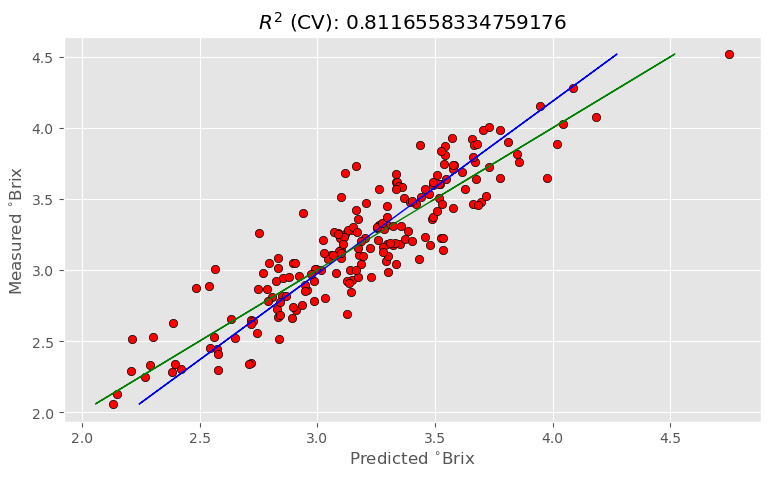

In [34]:
opt_Xc, ncomp, wav, sorted_ind = pls_variable_selection(X, y, 15)
simple_pls_cv(opt_Xc, y, ncomp)

/var/folders/k9/rhnn5sp15y734327p_mzl2m00000gn/T/ipykernel_31501/1906345759.py:17: MatplotlibDeprecationWarning: The span_where function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use fill_between instead.
  collection = collections.BrokenBarHCollection.span_where(
/var/folders/k9/rhnn5sp15y734327p_mzl2m00000gn/T/ipykernel_31501/1906345759.py:17: MatplotlibDeprecationWarning: The BrokenBarHCollection class was deprecated in Matplotlib 3.7 and will be removed two minor releases later.
  collection = collections.BrokenBarHCollection.span_where(


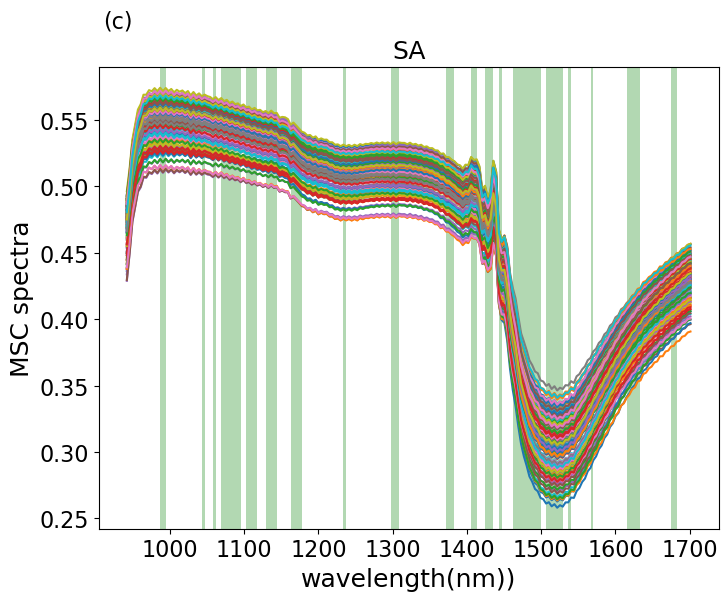

In [35]:
# Get a boolean array according to the indices that are being discarded
ix = np.in1d(wl.ravel(), wl[sorted_ind][:wav])

import matplotlib.collections as collections

# Plot spectra with superimpose selected bands
fig, ax = plt.subplots(figsize=(8,6))
with plt.style.context(()):
    ax.plot(wl, X.T)
    plt.text(910, 0.58, "(c)\n\n", fontsize=16, color='black') 
    plt.xticks(fontsize=16)  
    plt.yticks(fontsize=16) 
    plt.title('SA', fontsize=18)
    plt.ylabel('MSC spectra', fontsize=18)
    plt.xlabel('wavelength(nm))', fontsize=18)

collection = collections.BrokenBarHCollection.span_where(
    wl, ymin=-1, ymax=1, where=ix == True, facecolor='g', alpha=0.3)
ax.add_collection(collection)

plt.show()